# Análise Descritiva - Dashboard
##### O objetivo deste notebook é demonstrar as transformações de dados feitas no Power BI, assim como algumas das análises ali presentes, porém em código.

## 1. Importações

In [1]:
import pandas as pd
from dateutil import parser
import matplotlib.pyplot as plt
import seaborn as sns

## 1.1 Configurações de display do Pandas

In [2]:
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', None)

## 2. Leitura dos dados base

In [3]:
df = pd.read_csv('../dados-transformados/ViewingActivityDateFiltered.csv')

display(df)


,Duration,Start Time,Profile Name,Country,Bookmark,Latest Bookmark,Supplemental Video Type,Attributes,Device Type,Title
0,00:00:05,30-01-2026,Extra,BR (Brazil),00:56:20,00:56:20,NaN,NaN,DefaultWidevineAndroidPhone,Bridgerton: Temporada 1: Diamante raro (episód...
1,00:05:47,30-01-2026,Extra,BR (Brazil),00:54:40,Not latest view,NaN,NaN,DefaultWidevineAndroidPhone,Bridgerton: Temporada 1: Diamante raro (episód...
2,00:40:58,30-01-2026,Extra,BR (Brazil),00:40:09,Not latest view,NaN,NaN,DefaultWidevineAndroidPhone,Bridgerton: Temporada 1: Diamante raro (episód...
3,00:00:38,30-01-2026,Extra,BR (Brazil),00:25:59,00:25:59,NaN,NaN,DefaultWidevineAndroidPhone,Bridgerton: Temporada 4: Um Perfeito Cavalheir...
4,00:06:37,30-01-2026,Extra,BR (Brazil),00:20:14,00:20:14,NaN,NaN,Chrome OS (Cadmium),Dr. House: Temporada 5: Simple Explanation (ep...
...,...,...,...,...,...,...,...,...,...,...
14703,00:01:45,23-12-2023,Ryan,BR (Brazil),00:19:27,Not latest view,NaN,NaN,iPhone 12,Desejo Sombrio: Temporada 1: A idiotice chamad...
14704,00:00:04,23-12-2023,Ryan,BR (Brazil),00:33:37,00:33:37,NaN,NaN,iPhone 12,Desejo Sombrio: Temporada 1: Uma última noite ...
14705,00:00:56,20-12-2023,Ryan,BR (Brazil),00:41:37,00:41:37,NaN,NaN,iPhone 12,DNA DO CRIME: Temporada 1: Vestígios da Noite ...
14706,01:10:02,29-11-2023,Ryan,BR (Brazil),01:10:02,01:10:02,NaN,Autoplayed: user action: User_Interaction,,"LG 2017 LG M16p Standard UHD TV Smart TV,Paral..."


## 3. Formatação das datas no formato DD-MM-YYYY

In [4]:
def normalizar_data(valor):
    if pd.isna(valor):
        return valor
    try:
        return parser.parse(str(valor), dayfirst=True).strftime('%d-%m-%Y')
    except:
        return valor

df['Start Time'] = df['Start Time'].apply(normalizar_data)

df['Start Time dt'] = pd.to_datetime(df['Start Time'], format='%d-%m-%Y')
data_inicio = pd.to_datetime('2023-11-20')

df = df[(df['Start Time dt'] >= data_inicio)].copy()

df = df.drop(columns=['Start Time dt'])

display(df.sort_values(by='Start Time', ascending=True))

,Duration,Start Time,Profile Name,Country,Bookmark,Latest Bookmark,Supplemental Video Type,Attributes,Device Type,Title
7178,00:00:04,20-11-2023,Extra,BR (Brazil),00:00:04,Not latest view,HOOK,Autoplayed: user action: None;,Panasonic 2018 MT5811 4K FRCTcon TV Smart TV,The Girl with the Dragon Tattoo - CLM 4
7260,00:00:04,20-11-2023,Extra,BR (Brazil),00:00:04,00:00:04,HOOK,Autoplayed: user action: None;,Panasonic 2018 MT5811 4K FRCTcon TV Smart TV,Trolls - CLM 2
7259,00:00:03,20-11-2023,Extra,BR (Brazil),00:00:03,00:00:03,NaN,Autoplayed: user action: None;,Panasonic 2018 MT5811 4K FRCTcon TV Smart TV,Ben 10: Temporada 1: E então eram 10 (episódio 1)
7258,00:02:18,20-11-2023,Extra,BR (Brazil),00:02:18,00:02:18,NaN,NaN,Panasonic 2018 MT5811 4K FRCTcon TV Smart TV,Ben 10: Temporada 2: Verdade (episódio 1)
7257,00:00:56,20-11-2023,Extra,BR (Brazil),00:00:56,Not latest view,HOOK,Autoplayed: user action: None;,Panasonic 2018 MT5811 4K FRCTcon TV Smart TV,Unknown Title
...,...,...,...,...,...,...,...,...,...,...
7308,00:20:34,31-12-2025,João Vitor,BR (Brazil),00:45:02,00:45:02,NaN,NaN,TCL TV 2022 GTV RT51A Smart TV,Black Mirror: Temporada 7: Eulogy (episódio 5)
7309,00:26:29,31-12-2025,João Vitor,BR (Brazil),00:25:21,Not latest view,NaN,NaN,TCL TV 2022 GTV RT51A Smart TV,Black Mirror: Temporada 7: Eulogy (episódio 5)
7310,00:00:14,31-12-2025,João Vitor,BR (Brazil),00:00:14,Not latest view,HOOK,Autoplayed: user action: User_Interaction;,TCL TV 2022 GTV RT51A Smart TV,Temporada 7 (Clipe 4): Black Mirror
7304,00:00:15,31-12-2025,João Vitor,BR (Brazil),00:00:15,00:00:15,HOOK,Autoplayed: user action: None;,Apple iPhone 15 Pro Max iPhone,Masha and the Bear: Season 1_hook_02_16x9


## 4. Eliminação de colunas desnecessárias para a análise

In [5]:
df.drop(["Country", "Bookmark", "Latest Bookmark",
"Supplemental Video Type", "Attributes", "Device Type"], axis=1, inplace=True)

display(df.sort_values(by='Start Time', ascending=True))

,Duration,Start Time,Profile Name,Title
7178,00:00:04,20-11-2023,Extra,The Girl with the Dragon Tattoo - CLM 4
7260,00:00:04,20-11-2023,Extra,Trolls - CLM 2
7259,00:00:03,20-11-2023,Extra,Ben 10: Temporada 1: E então eram 10 (episódio 1)
7258,00:02:18,20-11-2023,Extra,Ben 10: Temporada 2: Verdade (episódio 1)
7257,00:00:56,20-11-2023,Extra,Unknown Title
...,...,...,...,...
7308,00:20:34,31-12-2025,João Vitor,Black Mirror: Temporada 7: Eulogy (episódio 5)
7309,00:26:29,31-12-2025,João Vitor,Black Mirror: Temporada 7: Eulogy (episódio 5)
7310,00:00:14,31-12-2025,João Vitor,Temporada 7 (Clipe 4): Black Mirror
7304,00:00:15,31-12-2025,João Vitor,Masha and the Bear: Season 1_hook_02_16x9


In [6]:
df['Start Time'] = pd.to_datetime(df['Start Time'], format='%d-%m-%Y')

df['dia_semana'] = df['Start Time'].dt.day_name(locale='pt_BR')

## 4.1 Verificação e formatação de colunas

In [7]:
df.columns = ['duration','start_time','profile_name', 'title', 'weekday']
df.isna().values.any()
df.dtypes

duration                object
start_time      datetime64[ns]
profile_name            object
title                   object
weekday                 object
dtype: object

## 4.2 Conferindo as datas de nossa base.

In [8]:
print("Data mínima:", df['start_time'].min())
print("Data máxima:", df['start_time'].max())

df['duration'] = pd.to_timedelta(df['duration'])

Data mínima: 2023-11-20 00:00:00
Data máxima: 2026-01-31 00:00:00


## 5. Criando coluna `type` para diferenciar Série e Filme

In [9]:
keywords = ['temporada', 'season', 'episode', 'episódio']

pattern = '|'.join(keywords)

df['type'] = df['title'].str.lower().str.contains(pattern, na=False).map({True: 'Série', False: 'Filme'})

df['type'].value_counts()

type
Série    9031
Filme    5677
Name: count, dtype: int64

In [10]:
display(df)

,duration,start_time,profile_name,title,weekday,type
0,0 days 00:00:05,2026-01-30,Extra,Bridgerton: Temporada 1: Diamante raro (episód...,Sexta-feira,Série
1,0 days 00:05:47,2026-01-30,Extra,Bridgerton: Temporada 1: Diamante raro (episód...,Sexta-feira,Série
2,0 days 00:40:58,2026-01-30,Extra,Bridgerton: Temporada 1: Diamante raro (episód...,Sexta-feira,Série
3,0 days 00:00:38,2026-01-30,Extra,Bridgerton: Temporada 4: Um Perfeito Cavalheir...,Sexta-feira,Série
4,0 days 00:06:37,2026-01-30,Extra,Dr. House: Temporada 5: Simple Explanation (ep...,Sexta-feira,Série
...,...,...,...,...,...,...
14703,0 days 00:01:45,2023-12-23,Ryan,Desejo Sombrio: Temporada 1: A idiotice chamad...,Sábado,Série
14704,0 days 00:00:04,2023-12-23,Ryan,Desejo Sombrio: Temporada 1: Uma última noite ...,Sábado,Série
14705,0 days 00:00:56,2023-12-20,Ryan,DNA DO CRIME: Temporada 1: Vestígios da Noite ...,Quarta-feira,Série
14706,0 days 01:10:02,2023-11-29,Ryan,"LG 2017 LG M16p Standard UHD TV Smart TV,Paral...",Quarta-feira,Filme


## 6. Análises Gerais

In [11]:
df['title'].value_counts()

title
Unknown Title                                                                                                        360
Temporada 1 (TRaisler): O Refúgio Atômico                                                                             32
Temporada 1 (TRaisler): A Hóspede                                                                                     30
Temporada 1 (TRaisler): House of Guinness                                                                             28
Temporada 1 (Clipe): Fishbowl Wives                                                                                   23
                                                                                                                    ... 
Beleza Verdadeira:  1: Episódio 3 (episódio 3)                                                                         1
MStar PureTurnkey51 Express luck 2K Smart TV,Beleza Verdadeira:  1: Episódio 4 (episódio 4)                            1
MStar PureTurnkey51 Expres

## 6.1 Removendo "Unknown Title"

In [12]:
df = df[df['title'] != 'Unknown Title']
df['title'].value_counts()

title
Temporada 1 (TRaisler): O Refúgio Atômico                    32
Temporada 1 (TRaisler): A Hóspede                            30
Temporada 1 (TRaisler): House of Guinness                    28
Temporada 1 (Clipe): Fishbowl Wives                          23
Guerreiras do K-Pop                                          23
                                                             ..
Enfermeira: Minissérie: No ritmo (episódio 1)                 1
Enfermeira: Minissérie: A dupla perfeita (episódio 2)         1
Dr. House: Temporada 5: The Social Contract (episódio 17)     1
Never Say Never Again_hook_04                                 1
Temporada 3 (Resumo): Bridgerton                              1
Name: count, Length: 6927, dtype: int64

## 6.2 - Análises por `profile_name`

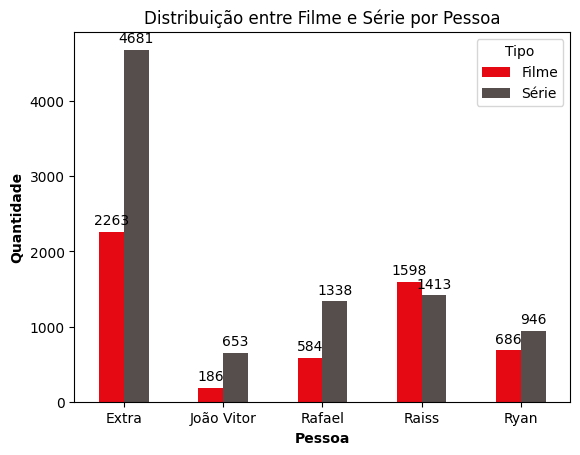

In [13]:
contagem = df.groupby(['profile_name', 'type']).size().unstack(fill_value=0)

cores = {
    'Filme': '#E50914',
    'Série': '#564d4d'
}

contagem.plot(kind='bar',color=[cores[c] for c in contagem.columns] )

plt.title('Distribuição entre Filme e Série por Pessoa')
plt.xlabel('Pessoa', fontweight="bold")
plt.ylabel('Quantidade', fontweight="bold")
plt.legend(title='Tipo')
plt.xticks(rotation=0)
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.show()

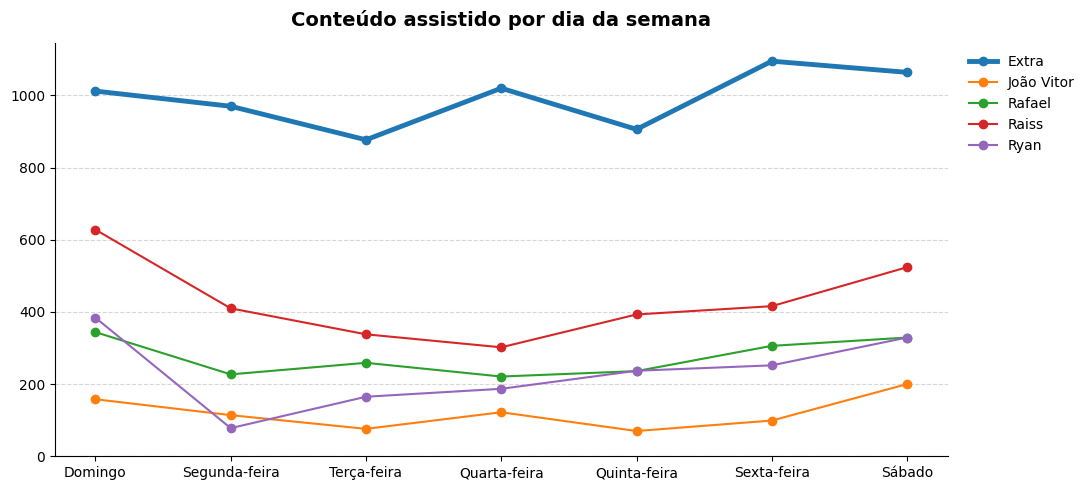

In [14]:
ordem_dias = ['Domingo','Segunda-feira', 'Terça-feira', 'Quarta-feira', 'Quinta-feira', 'Sexta-feira', 'Sábado']

contagem = df.groupby(['profile_name', 'weekday']).size().unstack(fill_value=0).reindex(columns=ordem_dias, fill_value=0)

fig, ax = plt.subplots(figsize=(11, 5))

for profile in contagem.index:
    lw = 3.5 if profile == 'Extra' else 1.5
    ax.plot(ordem_dias, contagem.loc[profile], marker='o', label=profile, linewidth=lw)

ax.set_ylim(0)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)
ax.set_title('Conteúdo assistido por dia da semana', fontsize=14, fontweight='bold', pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

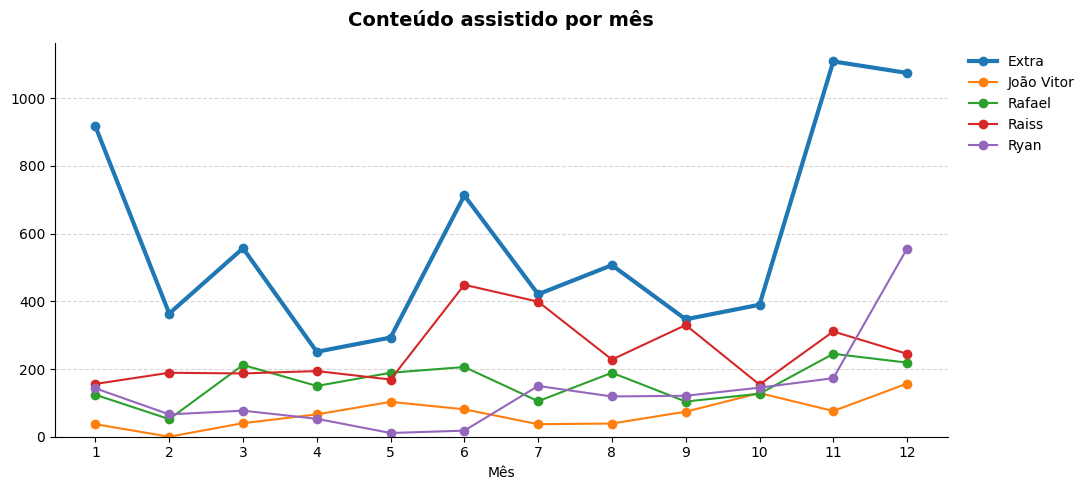

In [15]:
df['month'] = pd.to_datetime(df['start_time']).dt.month

contagem = df.groupby(['profile_name', 'month']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(11, 5))

for profile in contagem.index:
    lw = 3 if profile == 'Extra' else 1.5
    ax.plot(contagem.columns, contagem.loc[profile], marker='o', label=profile, linewidth=lw)

ax.set_ylim(0)
ax.set_xticks(range(1, 13))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)
ax.set_title('Conteúdo assistido por mês', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Mês')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

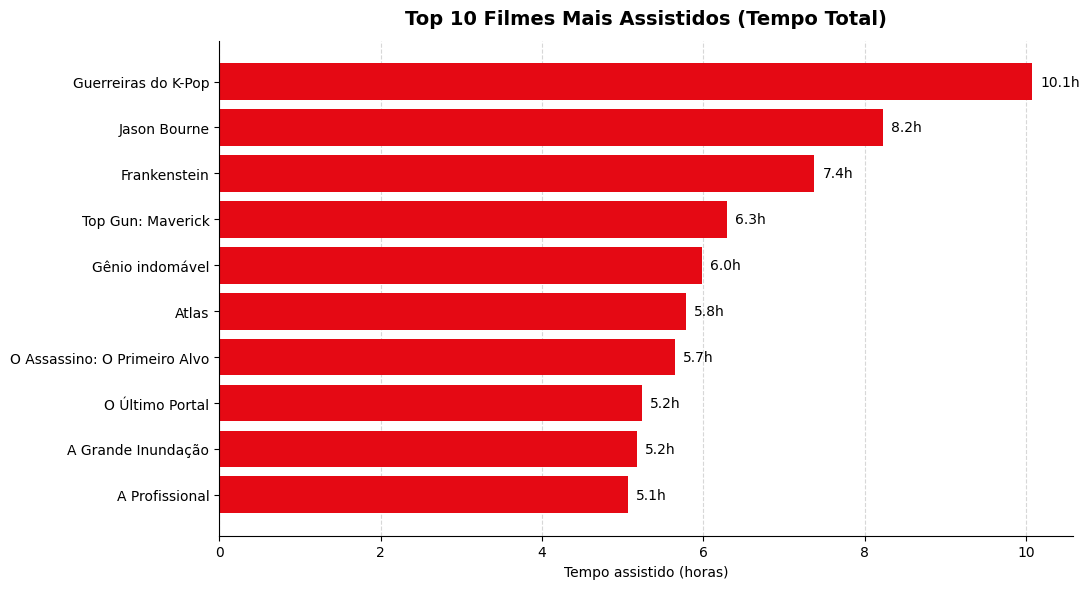

In [16]:
filmes = df[df['type'] == 'Filme'].copy()
filmes = filmes[filmes['title'].notna()]

top_filmes = (
    filmes.groupby('title')['duration'].sum()
    .sort_values(ascending=False).head(10)
)

top_filmes_horas = (top_filmes.dt.total_seconds() / 3600).sort_values()

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(top_filmes_horas.index, top_filmes_horas.values, color='#E50914', linewidth=0)

for i, v in enumerate(top_filmes_horas.values):
    ax.text(v + 0.1, i, f"{v:.1f}h", va='center')

ax.set_title("Top 10 Filmes Mais Assistidos (Tempo Total)", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Tempo assistido (horas)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

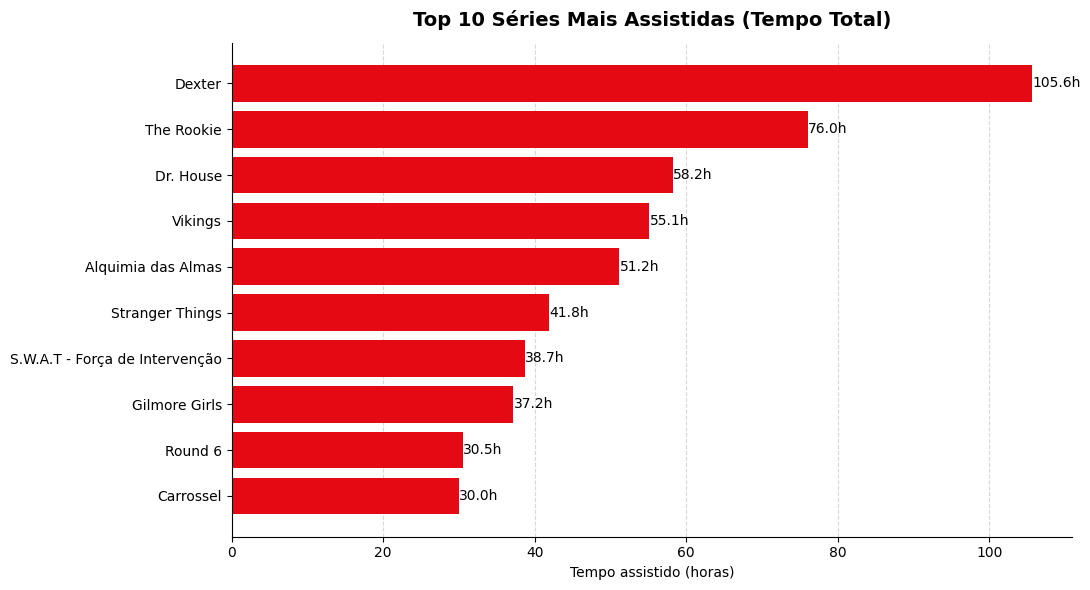

In [18]:
top_series = (
    df[df['type'] == 'Série']
    .assign(title_base = df['title'].str.split(':').str[0].str.strip())
    .groupby('title_base')['duration']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_series_horas = (top_series.dt.total_seconds() / 3600).sort_values()

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(top_series_horas.index, top_series_horas.values, color='#E50914', linewidth=0)

for i, v in enumerate(top_series_horas.values):
    ax.text(v + 0.05, i, f"{v:.1f}h", va='center')

ax.set_title("Top 10 Séries Mais Assistidas (Tempo Total)", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Tempo assistido (horas)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()